## Практикуемся решать задачу регрессии!

### Будем предсказывать цену дома 📝

ВАЖНО: При построении графиков не забывайте указать название графика и обозначить, что изображено по каждой из осей

В блоке ниже импортируйте все библиотеки, которые вам понадобятся для запуска ноутбука

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# some lib

**Скачайте необходимые данные по ссылке: https://www.kaggle.com/c/house-prices-advanced-regression-techniques**

In [ ]:
from google.colab import files
files.upload()

KeyboardInterrupt: 

In [ ]:
!mkdir -p ~/.kaggle #создаем директорию в папке
!cp kaggle.json ~/.kaggle/ # копирую в папку тот файл с ключом который загрузила выше
!chmod 600 ~/.kaggle/kaggle.json # редачу права пользователя на всякий случай
!kaggle competitions download -c house-prices-advanced-regression-techniques # качаю данные
!unzip house-prices-advanced-regression-techniques.zip

In [ ]:
data = pd.read_csv('train.csv', header=0)

✅ Посмотрите, как выглядят данные, и приступайте к анализу

In [ ]:
data.shape

(1460, 81)

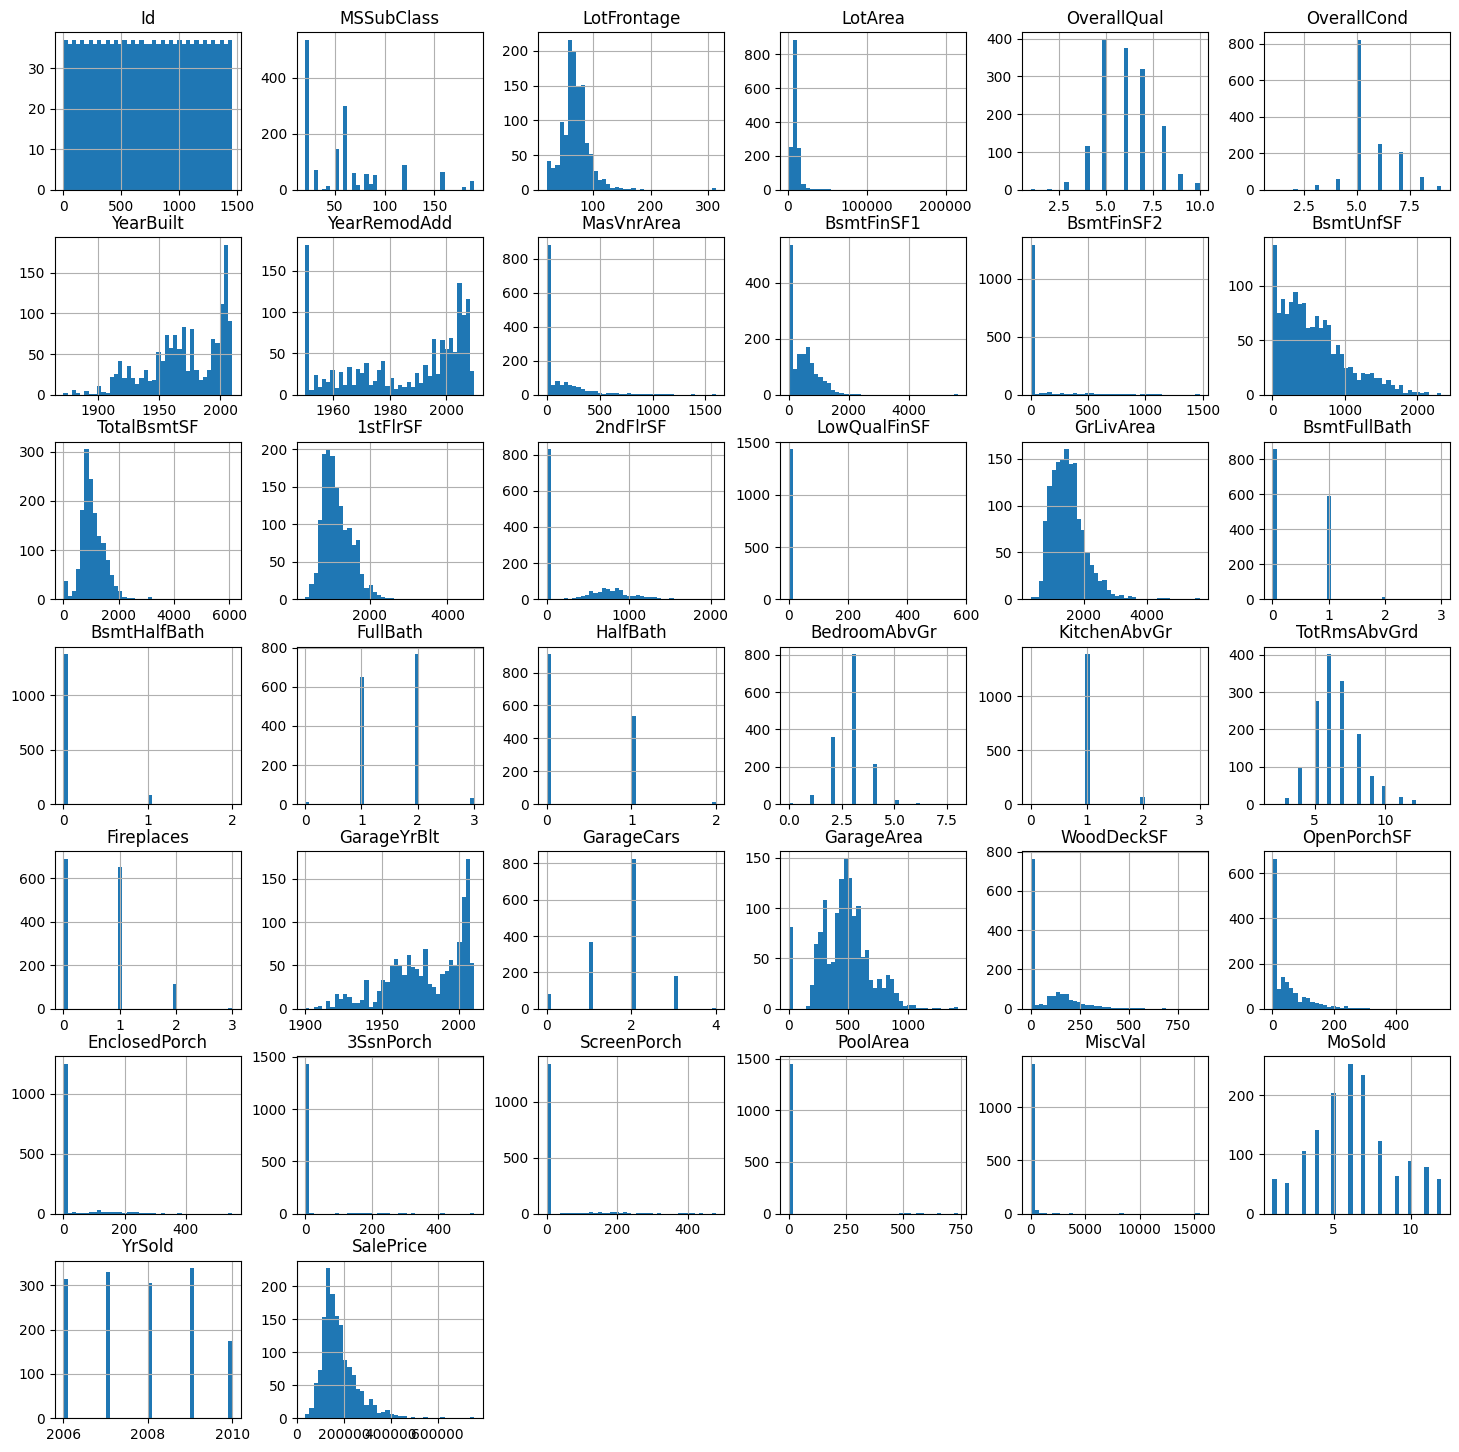

In [ ]:
datanum = data.select_dtypes(include = ['float64', 'int64'])
datanum.hist(figsize=(18, 18), bins=40);

In [ ]:
data.head()# надо удалить Id и последний столбец(записать его в другую переменную)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


✅ Если в данных бессмысленные столбцы? Если да, избавьтесь от них и объясните, почему так поступили.

In [ ]:
y_real=data['SalePrice']
data=data.drop(['Id'], axis=1)
# я бы если честно половину бы дропнула но боюсь что будет ошибка избирательности данных

✅ Есть ли в данных пропуски? Если да, то для каждого столбца, в котором они имеются, посчитайте их количество и их долю от общего числа значений. Что вы наблюдаете?

In [ ]:
null_data=data.isna().sum()
null_data=null_data[null_data>0]
null_data=null_data/1460 # в долевом отношении количество пропусков от размера массива
null_data.sort_values(ascending=False)
# удалю сразу где пропусков более 20%

,0
PoolQC,0.995205
MiscFeature,0.963014
Alley,0.937671
Fence,0.807534
MasVnrType,0.597260
FireplaceQu,0.472603
LotFrontage,0.177397
GarageType,0.055479
GarageYrBlt,0.055479
GarageFinish,0.055479


✅ Избавьтесь от пропусков. Для каждого из примененных методов обоснуйте свое решение.

In [ ]:
data=data.drop(['PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu'],axis=1)
'''
'PoolQC'- плохо заполнены
'MiscFeature'-плохо заполнены
'Alley'-плохо заполнены
'Fence'- плохо заполнены
'MasVnrType'-плохо заполнены, но уже сомнительно просто так выкидывать
но вероятно есть более важные признаки чем тип облицовки если посмотреть объективно
'FireplaceQu'-сложно дозаполнить и не стоит мучений

'''

"\n'PoolQC'- плохо заполнены\n'MiscFeature'-плохо заполнены\n'Alley'-плохо заполнены\n'Fence'- плохо заполнены\n'MasVnrType'-плохо заполнены, но уже сомнительно просто так выкидывать\nно вероятно есть более важные признаки чем тип облицовки если посмотреть объективно\n'FireplaceQu'-сложно дозаполнить и не стоит мучений\n\n"

✅ Проверьте, что вы действительно избавились от пропусков

In [ ]:
data.info()
#признаков так много что кажется что из них роляют ну с десяток не более

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   LotShape       1460 non-null   object 
 6   LandContour    1460 non-null   object 
 7   Utilities      1460 non-null   object 
 8   LotConfig      1460 non-null   object 
 9   LandSlope      1460 non-null   object 
 10  Neighborhood   1460 non-null   object 
 11  Condition1     1460 non-null   object 
 12  Condition2     1460 non-null   object 
 13  BldgType       1460 non-null   object 
 14  HouseStyle     1460 non-null   object 
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

In [ ]:
null_data=data.isna().sum()
null_data=null_data[null_data>0]
null_data

,0
LotFrontage,259
MasVnrArea,8
BsmtQual,37
BsmtCond,37
BsmtExposure,38
BsmtFinType1,37
BsmtFinType2,38
Electrical,1
GarageType,81
GarageYrBlt,81


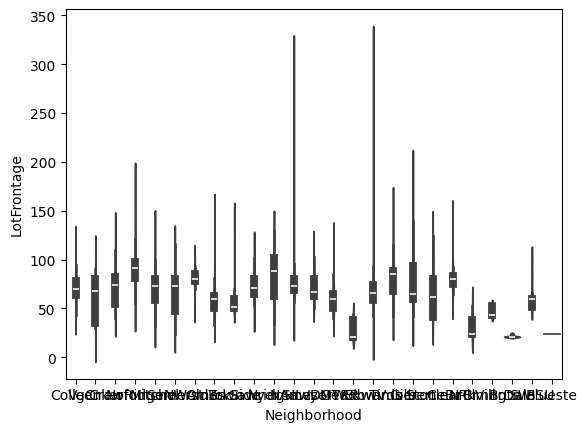

In [ ]:
sns.violinplot(x='Neighborhood', y='LotFrontage', data=data)
plt.show()
#можно было бы не мучаться и заполнить медианой но все равно чуть спокойнее когда действуешь по придуманной логике поэтому давайте заполнимм по медиане области
data['LotFrontage']=data.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

In [ ]:
data['MasVnrArea']=data['MasVnrArea'].fillna(0)#предположим что нет облицовки(там уже есть такие варианты)

#обратите вниманиеи что с подвалом примерно одинаковое количество пропусков вероятно просто в этих домах нет подвала
bsmt = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
data[bsmt] = data[bsmt].fillna('None')

data['Electrical']=data['Electrical'].fillna(data['Electrical'].mode()[0])

#та же ситуация что и с подвалами
garage = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
data[garage] = data[garage].fillna('None')
data['GarageYrBlt']=data['GarageYrBlt'].fillna(0)


✅ Обработайте категориальные признаки. Объясните выбор метода (one-hot-encoding, label encoding, ...)

In [ ]:
X_objects =data.select_dtypes(include=['object'])
X_objects.columns

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import OneHotEncoder
data_corr= data.select_dtypes(include ='number')
ohe= OneHotEncoder(drop='first')
X_objects = data.select_dtypes(include=['object'])
x= ohe.fit(X_objects)
codes= ohe.transform(X_objects).toarray()
features_names=ohe.get_feature_names_out(X_objects.columns)
data_coded = pd.concat([data_corr, pd.DataFrame(codes, columns= features_names).astype(int)], axis=1)


In [ ]:
data_coded.shape

(1460, 239)

✅ Вычислите и визуализируйте попарную корреляцию Пирсона между всеми признаками. Какие выводы можно сделать?

'очень тяжело идет задание\nпосмотрим на столбец SalePrice(я не переставляла его в конеу он после числовых идет)\nвидим что почти все категориальные не имеют высокой кореляции кроме(KitchenQual_TA,ExterQual_TA)\nплюс категориальные со значениями None коррелируют с значением от 0.9-1\n'

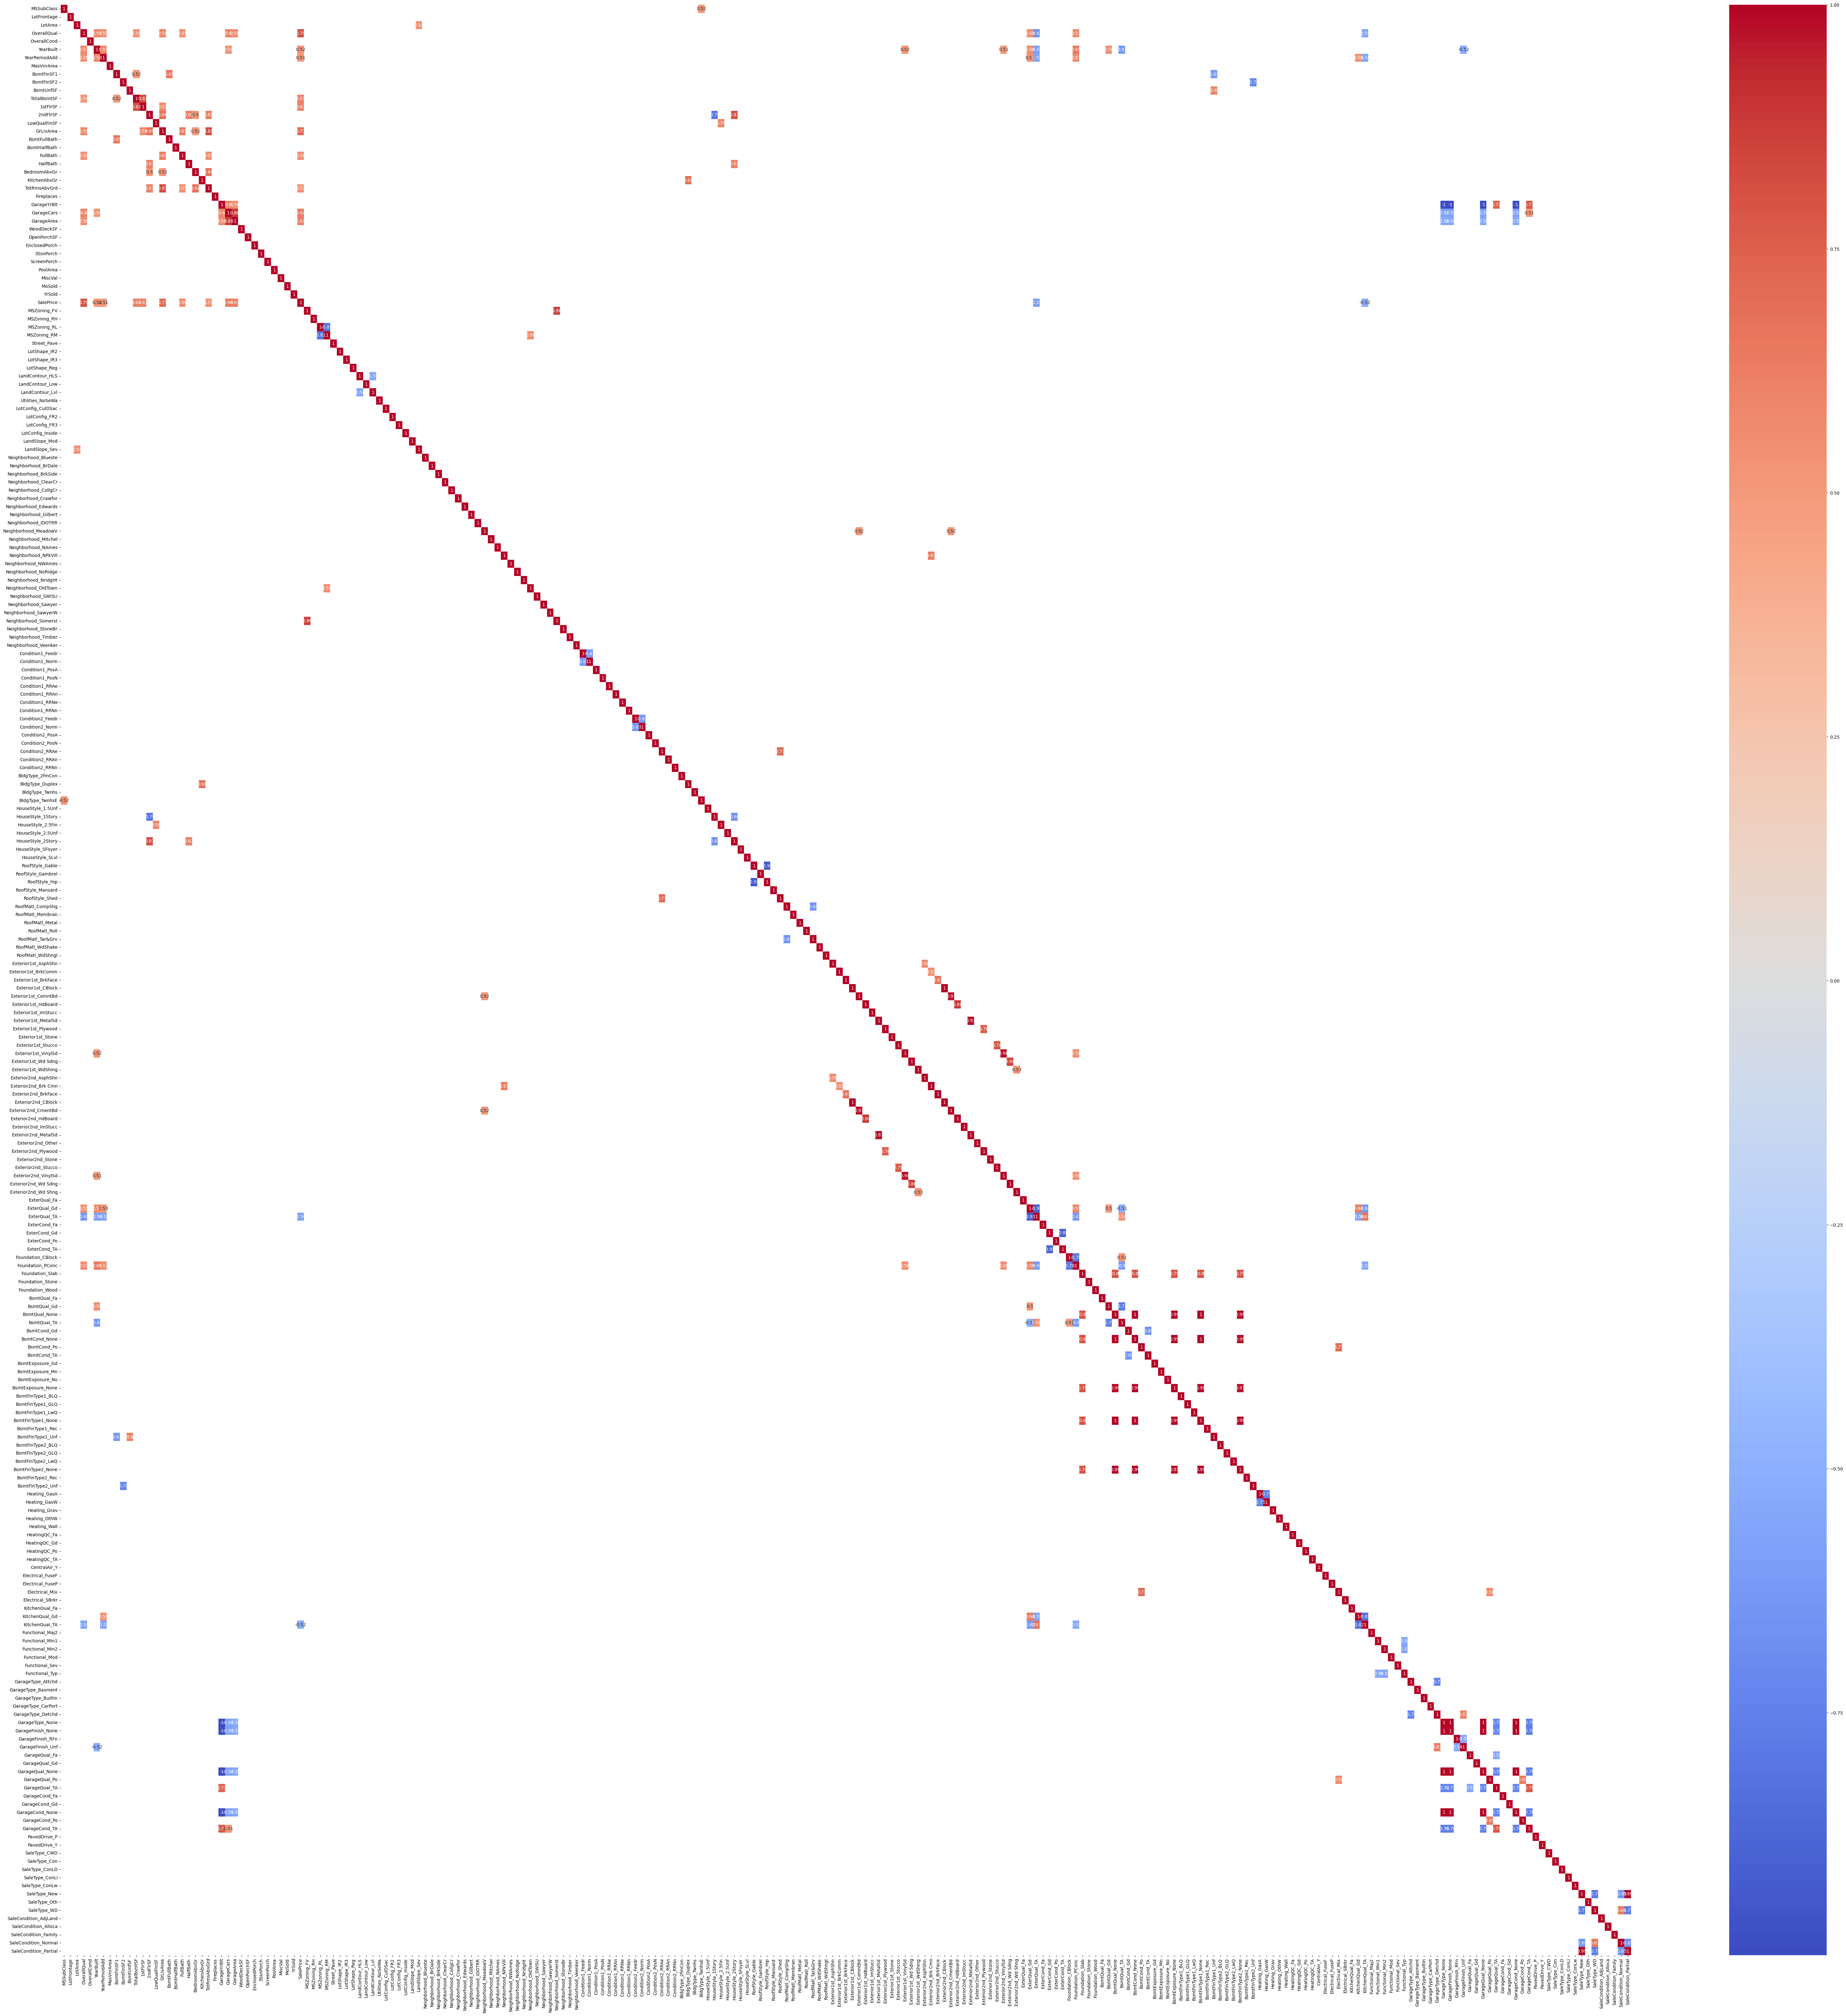

In [ ]:
correlation_matrix = data_coded.corr()
plt.figure(figsize=(80, 80))
strong_corr = correlation_matrix[abs(correlation_matrix) > 0.5]#для более простой визуализации
sns.heatmap(strong_corr, cmap='coolwarm', annot=True)
'''очень тяжело идет задание
посмотрим на столбец SalePrice(я не переставляла его в конец он после числовых идет)
видим что почти все категориальные не имеют высокой кореляции кроме(KitchenQual_TA,ExterQual_TA)
плюс категориальные со значениями None коррелируют с значением от 0.9-1
'''

✅ Найдите признаки с максимальным и минимальным абсолютным значением коэффициента корреляции Пирсона с предсказываемым значением. Изобразите на графиках зависимость найденных признаков от предсказываемого значения.

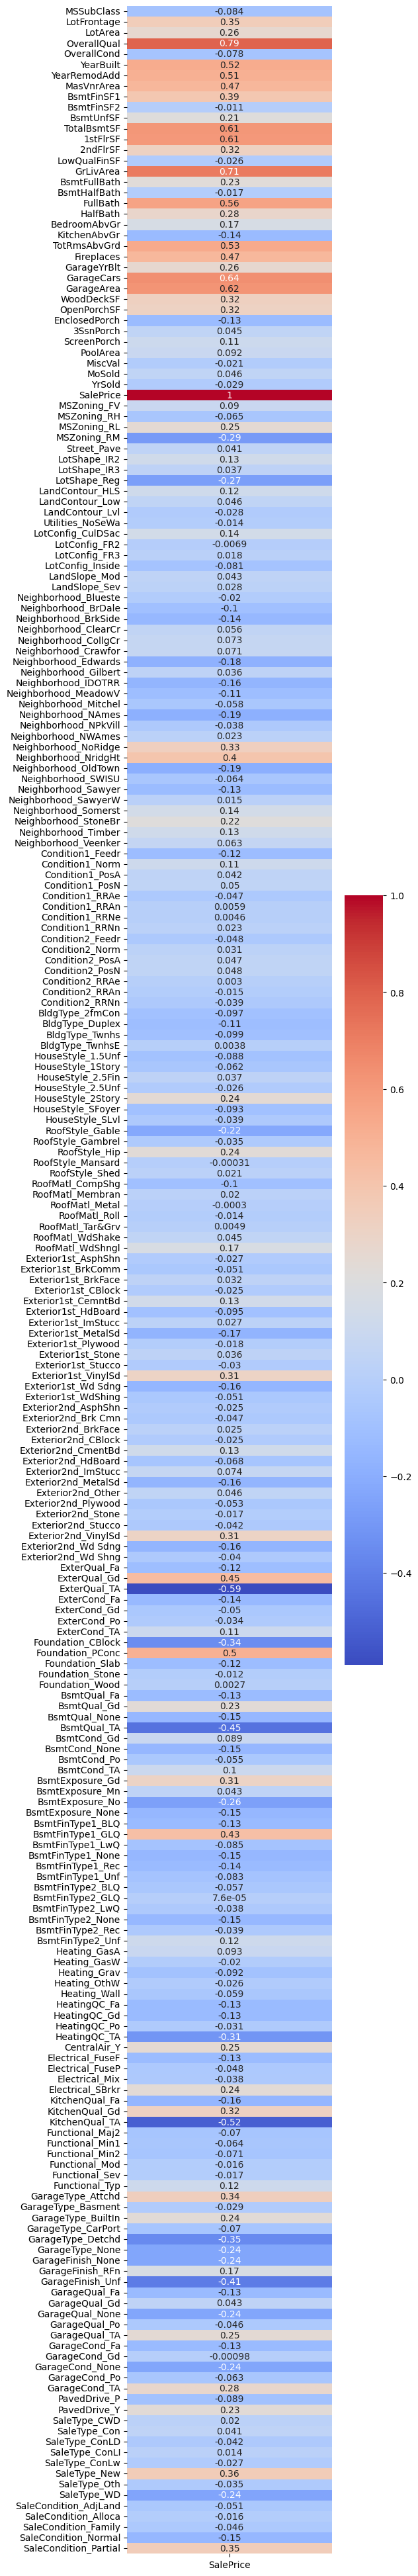

In [ ]:
corr_for_sale_price = correlation_matrix['SalePrice']
corr_for_sale_price = pd.DataFrame(corr_for_sale_price)
plt.figure(figsize=(5, 50))
sns.heatmap(corr_for_sale_price, cmap="coolwarm",annot=True)
plt.show()

In [ ]:
answer_max_min=corr_for_sale_price.abs().sort_values(by='SalePrice',ascending=False)
print(f"Признак с максимальной корреляцией({answer_max_min.index[1]}):", answer_max_min['SalePrice'].iloc[1])
print(f"Признак с минимальной корреляцией({answer_max_min.index[-1]}):", answer_max_min['SalePrice'].iloc[-1])

Признак с максимальной корреляцией(OverallQual): 0.7909816005838053
Признак с минимальной корреляцией(BsmtFinType2_GLQ): 7.551406179755978e-05


✅ Постройте гистограмму распределения предсказываемого значения. Для избавления от разницы в масштабах, а также "смещения" распределения переменной в сторону нормального, можно прологарифмировать ее (это обратимое преобразование, поэтому целевую переменную легко восстановить).

Подсказка: воспользуйтесь `numpy.log1p`, чтобы сделать преобразование $y \to \ln\left(1 + y\right)$. Постройте гистограмму распределения от нового предсказываемого значения. Опишите наблюдения.

ВАЖНО: далее используйте в качестве предсказываемого значения вектор, который получился после логарифмирования.

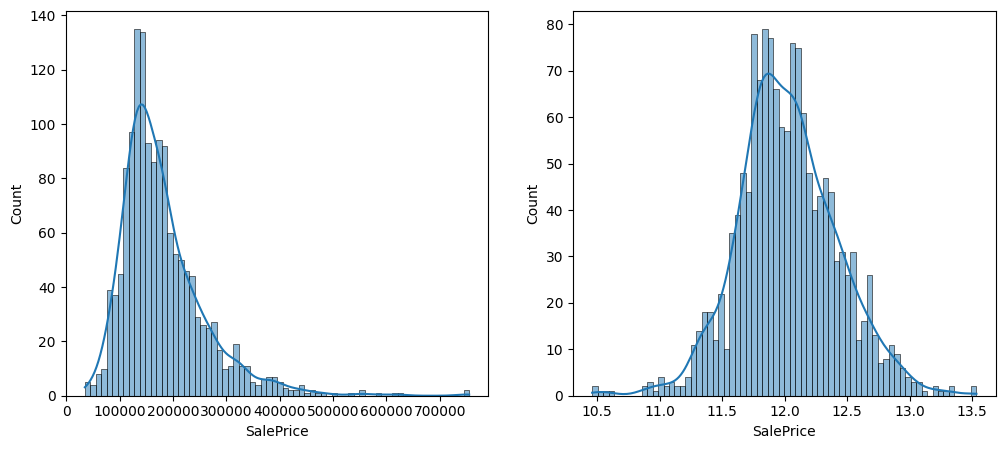

In [ ]:
log_saleprice=np.log1p(data['SalePrice'])
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data["SalePrice"], bins=70, kde=True)

plt.subplot(1, 2, 2)
sns.histplot(log_saleprice, bins=70, kde=True)

plt.show()#стало похоже на нормальное распределение

✅ Разбейте выборку на обучающую и тестовую в отношении 75:25. Зафиксируйте при разбиении значение `random_state` = 13. Не забывайте прологорифмировать целевую переменную (как в предыдущем задании)

In [ ]:
X= data_coded.drop('SalePrice',axis=1)
y= log_saleprice

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=13)

✅ Примените к данным

- Линейную регрессию
- Lasso
- Ridge

Для каждого из методов подберите гиперпараметры с помощью кросс-валидации. Обучите алгоритмы с лучшими гиперпараметрами на обучающей выборке и оцените качество по метрикам
- RMSE
- MAE
- $R^2$

Опишите полученные результаты.

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler =StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

def print_metrics(y_true, y_pred, dataset_name):
    print(f"RMSE {dataset_name} : {np.sqrt(mean_squared_error(y_true, y_pred))}")
    print(f"MAE {dataset_name} : {mean_absolute_error(y_true, y_pred)}")
    print(f"R2 {dataset_name} : {r2_score(y_true, y_pred)}\n")


print_metrics(y_train, lin_reg.predict(X_train), "Train")
print_metrics(y_test, lin_reg.predict(X_test), "Test")

#заметно переобучение

RMSE Train : 0.08603739098609646
MAE Train : 0.062000543160947844
R2 Train : 0.9529837478773556

RMSE Test : 0.21595361076919678
MAE Test : 0.10365661849029824
R2 Test : 0.7175182797448395



In [ ]:
lasso_cv=LassoCV(alphas=np.logspace(-4, 0, 100),cv=5)#логарифмическая шкала круче тк там при маленьких значениях больше точек
lasso_cv.fit(X_train, y_train)
print(lasso_cv.alpha_)
print_metrics(y_train, lasso_cv.predict(X_train), "Train")
print_metrics(y_test, lasso_cv.predict(X_test), "Test")

0.0031257158496882354
RMSE Train : 0.0967824446871584
MAE Train : 0.06959657280887127
R2 Train : 0.9405068837231626

RMSE Test : 0.2157504378314648
MAE Test : 0.09916536401624088
R2 Test : 0.7180495572053534



In [ ]:
ridge_cv=RidgeCV(alphas=np.logspace(-1, 4, 100),cv=5)
ridge_cv.fit(X_train, y_train)
print(ridge_cv.alpha_)
print_metrics(y_train, ridge_cv.predict(X_train), "Train")
print_metrics(y_test, ridge_cv.predict(X_test), "Test")#видим что уменьшении весов сработало лучше тк много коррелирующих данных

'''ну если честно результаты на всех моделях плохие, вероятно надо было получше обработать признаки '''

151.99110829529332
RMSE Train : 0.09193206630508208
MAE Train : 0.06574239819650747
R2 Train : 0.9463206083574053

RMSE Test : 0.20574662485494213
MAE Test : 0.10076318042053885
R2 Test : 0.7435900648990446



✅ Постройте гистограммы значений весов для линейной регрессии, Lasso и Ridge. Опишите наблюдения, проанализируйте результаты.

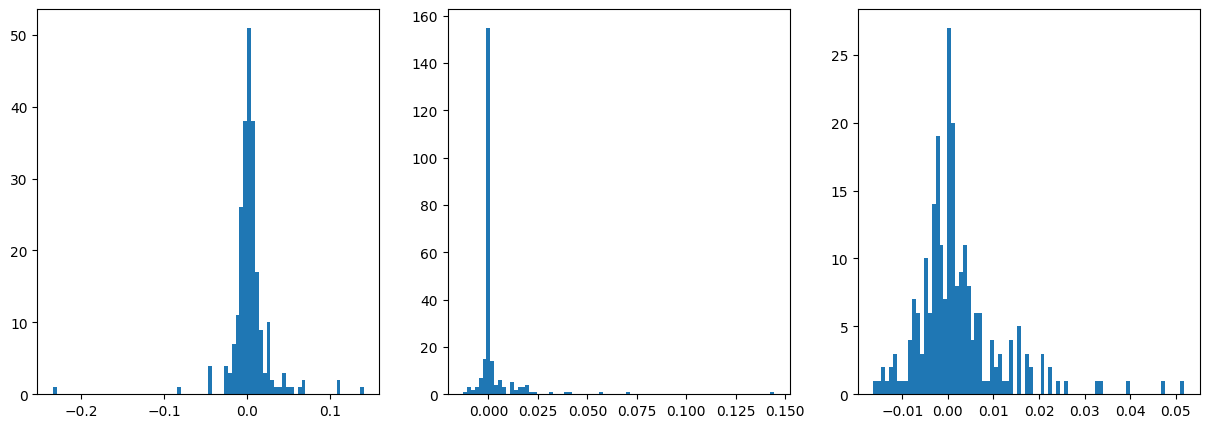

'\nкак раз хорошо заметно что в лассо веса обнуляются, но самые главный признак приобрел большой вес\nа в л2 регуляризации веса в отличие от линейной регрессии стали поменьше\n'

In [ ]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.hist(lin_reg.coef_, bins=80)

plt.subplot(1, 3, 2)
plt.hist(lasso_cv.coef_, bins=80)

plt.subplot(1, 3, 3)
plt.hist(ridge_cv.coef_, bins=80)
plt.show()
'''
как раз хорошо заметно что в лассо веса обнуляются, но самые главный признак приобрел большой вес
а в л2 регуляризации веса в отличие от линейной регрессии стали поменьше
'''